In [2]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.model_selection import GridSearchCV


In [3]:
# read data from repository
X_test = pd.read_csv('X_test.csv')
X_train = pd.read_csv('X_train.csv')
y_test = pd.read_csv('y_test.csv')
y_train = pd.read_csv('y_train.csv')

# compare y values in test and train sets
print(y_train.describe())
print(y_test.describe())

        is_canceled
count  69782.000000
mean       0.276017
std        0.447028
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
        is_canceled
count  17446.000000
mean       0.272097
std        0.445052
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000


In [4]:
# tree 1 without any constaints

tree_1 = tree.DecisionTreeClassifier(random_state= 12345)

tree_1.fit(X_train, y_train)

y_results = tree_1.predict(X_test)
y_results_proba = tree_1.predict_proba(X_test)

print(accuracy_score(y_test, y_results))

print(tree_1.get_depth())
print(tree_1.get_n_leaves())
# tree.plot_tree(tree_1)

# massive depth and number of leaves - pretty impossible to be plotted

0.7617218846727043
46
12397


0.7898085521036341
5
26


[Text(0.5138888888888888, 0.9166666666666666, 'x[0] <= 11.5\ngini = 0.4\nsamples = 69782\nvalue = [50521, 19261]'),
 Text(0.23333333333333334, 0.75, 'x[0] <= 7.5\ngini = 0.184\nsamples = 17518\nvalue = [15723, 1795]'),
 Text(0.3736111111111111, 0.8333333333333333, 'True  '),
 Text(0.1111111111111111, 0.5833333333333334, 'x[17] <= 0.5\ngini = 0.152\nsamples = 14586\nvalue = [13373, 1213]'),
 Text(0.08888888888888889, 0.4166666666666667, 'x[0] <= 1.5\ngini = 0.175\nsamples = 12527\nvalue = [11314, 1213]'),
 Text(0.044444444444444446, 0.25, 'x[13] <= 0.5\ngini = 0.13\nsamples = 6249\nvalue = [5814, 435]'),
 Text(0.022222222222222223, 0.08333333333333333, 'gini = 0.145\nsamples = 5130\nvalue = [4726, 404]'),
 Text(0.06666666666666667, 0.08333333333333333, 'gini = 0.054\nsamples = 1119\nvalue = [1088, 31]'),
 Text(0.13333333333333333, 0.25, 'x[18] <= 0.5\ngini = 0.217\nsamples = 6278\nvalue = [5500, 778]'),
 Text(0.1111111111111111, 0.08333333333333333, 'gini = 0.269\nsamples = 3284\nvalue 

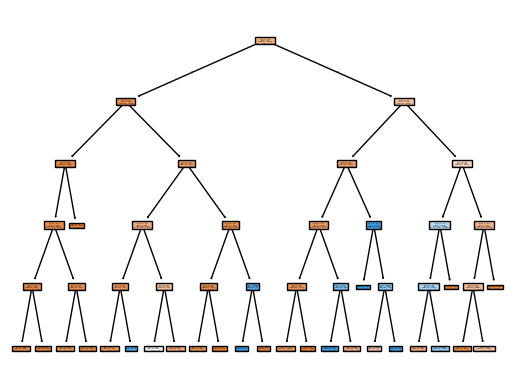

In [5]:
tree_2 = tree.DecisionTreeClassifier(max_depth=5, random_state=12345)

model = tree_2.fit(X_train, y_train)

y_results = tree_2.predict(X_test)
y_results_proba = tree_2.predict_proba(X_test)

print(accuracy_score(y_test, y_results))

print(tree_2.get_depth())
print(tree_2.get_n_leaves())
tree.plot_tree(tree_2, filled=True)


In [6]:
# Cut the first tree using CCP_alpha

path = tree_1.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas

# OPTIMIZATION: Take only meaningful alphas
meaningful_alphas = ccp_alphas[ccp_alphas > 0.0001]
print(len(meaningful_alphas))

trees = []

for ccp_alpha in meaningful_alphas:
    tree_cur = tree.DecisionTreeClassifier(random_state=12345, ccp_alpha=ccp_alpha)
    tree_cur.fit(X_train, y_train)
    trees.append(tree_cur)

print(len(trees))

110
110


In [7]:
results = []

for tree_current in trees:
    prediction = tree_current.predict(X_test)
    result = accuracy_score(y_test, prediction) * 100
    results.append(result)

dep = []
leav = []
for tree_current in trees:
    depth = tree_current.get_depth()
    leave = tree_current.get_n_leaves()
    dep.append(depth)
    leav.append(leave)

print(dep)
print(leav)

best = 0.0000
best_num = 0
for i, percentage in enumerate(results):
    if percentage > best:
        best = percentage
        best_num = i

print(f"Best Accuracy on test:{best:.2f}%, iteration number: {best_num} - ccp_alpha: {meaningful_alphas[best_num]}, layers: {trees[best_num].get_depth()}")


[18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 9, 9, 9, 9, 9, 9, 8, 8, 7, 6, 5, 5, 4, 4, 4, 3, 3, 1, 0]
[np.int64(152), np.int64(151), np.int64(149), np.int64(147), np.int64(146), np.int64(144), np.int64(143), np.int64(142), np.int64(141), np.int64(139), np.int64(137), np.int64(136), np.int64(135), np.int64(132), np.int64(131), np.int64(130), np.int64(129), np.int64(127), np.int64(126), np.int64(125), np.int64(123), np.int64(122), np.int64(121), np.int64(119), np.int64(118), np.int64(117), np.int64(115), np.int64(114), np.int64(113), np.int64(111), np.int64(110), np.int64(108), np.int64(107), np.int64(103), np.int64(101), np.int64(100), np.int64(99), np.int64(98), np.int64(

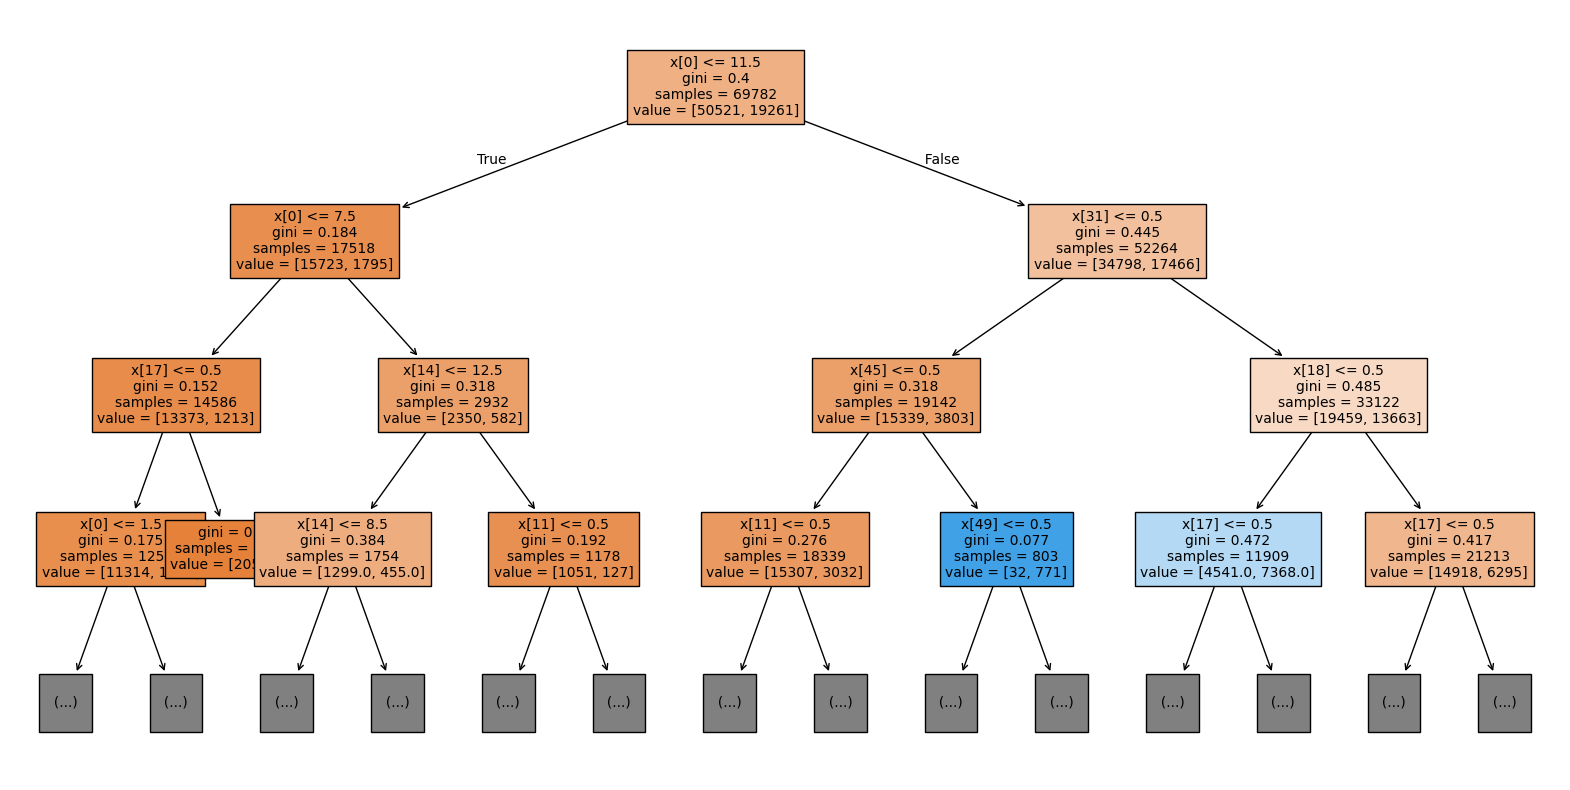

In [8]:
import matplotlib.pyplot as plt

best_tree = trees[best_num]

plt.figure(figsize=(20, 10))

tree.plot_tree(best_tree, max_depth=3, filled=True, fontsize=10)
plt.show()

In [9]:
#Data Preparation
df = pd.read_csv('hotel_bookings.csv', na_values=['NULL', 'NaN'])

#Usunięcie duplikatów

initial_len = len(df)
df_clean = df.drop_duplicates().copy()
print(f"Usunięto {initial_len - len(df_clean)} duplikatów.")

#Uzupełnienie brakujących danych
df_clean['children'] = df_clean['children'].fillna(0)
df_clean['agent'] = df_clean['agent'].fillna(0)
df_clean['country'] = df_clean['country'].fillna('Unknown')  # Zatrzymujemy kolumnę!

#Usunięcie kolumny company
df_clean.drop(columns=['company'], inplace=True, errors='ignore')

#Usunięcie rekordów z błędnym ADR i rezerwacji z brakiem gości
df_clean = df_clean[(df_clean['adr'] >= 0) & (df_clean['adr'] < 1000)]
df_clean = df_clean[(df_clean['adults'] + df_clean['children'] + df_clean['babies']) > 0]

#Usunięcie wycieków danych
leaked_cols = ['reservation_status', 'reservation_status_date', 'assigned_room_type']
df_clean.drop(columns=leaked_cols, inplace=True, errors='ignore')

#Weryfikacja końcowa
print(f"Podsumowanie czyszczenia")
print(f"Pozostało wierszy: {len(df_clean)}")
print(f"Brakujące wartości po czyszczeniu: {df_clean.isnull().sum().sum()}")

Usunięto 31994 duplikatów.
Podsumowanie czyszczenia
Pozostało wierszy: 87228
Brakujące wartości po czyszczeniu: 0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# Zmiana tekstu na liczby + chronologia
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_clean['arrival_date_month'] = df_clean['arrival_date_month'].map(month_map)

# Inżynieria nowych cech
df_clean['total_nights'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']
df_clean['total_guests'] = df_clean['adults'] + df_clean['children'] + df_clean['babies']

# Usunięcie zmiennej country
if 'country' in df_clean.columns:
    df_clean = df_clean.drop(columns=['country'])

# Ordinal Encoding zamiast One-Hot Encoding
cols_to_encode = ['hotel', 'meal', 'market_segment',
                  'distribution_channel', 'reserved_room_type',
                  'deposit_type', 'customer_type']

encoder = OrdinalEncoder()
# Transformacja w miejscu - tekst zamienia się na liczby zmiennoprzecinkowe (0.0, 1.0, 2.0...)
df_clean[cols_to_encode] = encoder.fit_transform(df_clean[cols_to_encode])

df_final = df_clean.copy()

# Weryfikacja końcowa
print(f"Zakończono! Liczba wierszy: {df_final.shape[0]}, Liczba kolumn: {df_final.shape[1]}")

#Przygotowanie zbioru danych do dalszej pracy

#Wyodrębnienie X oraz y
X = df_final.drop(columns=['is_canceled', 'country'], errors='ignore')
y = df_final['is_canceled']

#Podział na zbiór treningowy i testowy
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

Zakończono! Liczba wierszy: 87228, Liczba kolumn: 29


In [11]:
# tree approach2 - new data without any constaints

tree_new = tree.DecisionTreeClassifier(random_state= 12345)

tree_new.fit(X_train2, y_train2)

y_results2 = tree_new.predict(X_test2)
y_results_proba2 = tree_new.predict_proba(X_test2)

print(accuracy_score(y_test2, y_results2))

print(tree_new.get_depth())
print(tree_new.get_n_leaves())

# massive depth and number of leaves - pretty impossible to be plotted

0.7610913676487447
44
12429


In [12]:
# Cut the first tree using CCP_alpha

path = tree_new.cost_complexity_pruning_path(X_train2, y_train2)

ccp_alphas = path.ccp_alphas

# OPTIMIZATION: Take only meaningful alphas
meaningful_alphas = ccp_alphas[ccp_alphas > 0.0001]
print(len(meaningful_alphas))

trees = []

for ccp_alpha in meaningful_alphas:
    tree_cur = tree.DecisionTreeClassifier(random_state=12345, ccp_alpha=ccp_alpha)
    tree_cur.fit(X_train2, y_train2)
    trees.append(tree_cur)

print(len(trees))

103
103


In [14]:
results = []

for tree_current in trees:
    prediction = tree_current.predict(X_test2)
    result = accuracy_score(y_test2, prediction) * 100
    results.append(result)

dep = []
leav = []
for tree_current in trees:
    depth = tree_current.get_depth()
    leave = tree_current.get_n_leaves()
    dep.append(depth)
    leav.append(leave)

print(dep)
print(leav)

best = 0.0000
best_num = 0
for i, percentage in enumerate(results):
    if percentage > best:
        best = percentage
        best_num = i

print(
    f"Best Accuracy on test:{best:.2f}%, iteration number: {best_num} - ccp_alpha: {meaningful_alphas[best_num]}, layers: {trees[best_num].get_depth()}")


[18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 15, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 12, 12, 12, 12, 12, 12, 12, 12, 12, 11, 11, 11, 11, 11, 11, 11, 11, 11, 8, 7, 6, 6, 5, 4, 4, 4, 3, 3, 1, 0]
[np.int64(151), np.int64(150), np.int64(148), np.int64(146), np.int64(143), np.int64(141), np.int64(140), np.int64(139), np.int64(138), np.int64(137), np.int64(136), np.int64(135), np.int64(133), np.int64(131), np.int64(130), np.int64(129), np.int64(128), np.int64(126), np.int64(125), np.int64(124), np.int64(123), np.int64(122), np.int64(120), np.int64(119), np.int64(118), np.int64(116), np.int64(113), np.int64(110), np.int64(106), np.int64(104), np.int64(103), np.int64(102), np.int64(101), np.int64(98), np.int64(97), np.int64(96), np.int64(95), np.int64(94), np.int64(90), np.int64(89), np.in